# 3.5 Latent Dimensions and Brain Regions

This notebook investigates which brain regions each latent dimension encodes by:
1. Generating activation maps for top latent dimensions
2. Analyzing spatial patterns in the learned representations
3. Correlating latent features with brain anatomy (ROI analysis)
4. Identifying region-specific encoding patterns

## Methods:
- **Activation Maps**: Visualize which brain voxels activate for each latent dimension
- **ROI Analysis**: Correlate latent features with predefined brain regions (caudate, putamen)
- **Spatial Clustering**: Identify if dimensions encode specific anatomical regions
- **Gradient Analysis**: Examine how latent values change across brain space

## Expected Outcomes:
- Identify if latent_93, latent_5, latent_25 correspond to specific brain regions
- Determine if dimensions are region-specific or distributed
- Validate that learned features align with known dopamine pathology patterns

## Section 1: Setup and Model Loading

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import nibabel as nib
from scipy import stats
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("Libraries imported successfully!")

Device: cuda
Libraries imported successfully!


### 1.2 Define Constants and Brain Regions

In [2]:
# Top latent dimensions to analyze
TOP_LATENT_DIMS = {
    'SBR_PC1': ['latent_93', 'latent_5', 'latent_116', 'latent_1', 'latent_73'],
    'SBR_PC2': ['latent_25', 'latent_187', 'latent_114', 'latent_93', 'latent_159'],
    'SBR_PC3': ['latent_53', 'latent_22', 'latent_142', 'latent_33', 'latent_42']
}

# Brain regions of interest (from SBR data)
BRAIN_REGIONS = {
    'Caudate_R': 'DATSCAN_CAUDATE_R',
    'Caudate_L': 'DATSCAN_CAUDATE_L',
    'Putamen_R': 'DATSCAN_PUTAMEN_R',
    'Putamen_L': 'DATSCAN_PUTAMEN_L',
    'Putamen_R_Ant': 'DATSCAN_PUTAMEN_R_ANT',
    'Putamen_L_Ant': 'DATSCAN_PUTAMEN_L_ANT'
}

# Model parameters
LATENT_DIM = 256
FEATURE_COLS = [f'latent_{i}' for i in range(LATENT_DIM)]
SBR_COLS = list(BRAIN_REGIONS.values())

print(f"Top latent dimensions to analyze: {sum(len(v) for v in TOP_LATENT_DIMS.values())} total")
print(f"Brain regions: {len(BRAIN_REGIONS)}")
print(f"Latent dimensions: {LATENT_DIM}")

Top latent dimensions to analyze: 15 total
Brain regions: 6
Latent dimensions: 256


### 1.3 Load Data

In [3]:
# Load merged clinical/demographic data
# df_merged = pd.read_csv('output/merged_data.csv')
# print(f"Merged clinical data shape: {df_merged.shape}")

# # Load train set latent vectors
# latent_file = 'output/Experiments/LatentVectorAnalysis/train_latent_vectors_with_patno.csv'
# df_latent = pd.read_csv(latent_file)
# print(f"Train set latent vectors loaded: {df_latent.shape}")

# # Merge datasets
# df_latent_clean = df_latent.dropna(subset=['PATNO']).copy()
# df_combined = pd.merge(df_latent_clean, df_merged, on='PATNO', how='inner')
# print(f"Combined dataset: {df_combined.shape}")

df_combined = pd.read_csv('output/final_train_combined_ae_data.csv')

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Unique patients in combined data: {df_combined['PATNO'].nunique()}")

# Check for multiple visits per patient
visits_per_patient = df_combined.groupby('PATNO').size()
print(f"\nVisits per patient statistics:")
print(visits_per_patient.describe())
print(f"Patients with multiple visits: {(visits_per_patient > 1).sum()}")

# Filter for complete SBR data
df_sbr = df_combined.dropna(subset=SBR_COLS).copy()
print(f"Dataset with complete SBR data: {df_sbr.shape}")

Combined dataset shape: (2332, 304)
Unique patients in combined data: 1406

Visits per patient statistics:
count    1406.000000
mean        1.658606
std         0.951541
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
dtype: float64
Patients with multiple visits: 539
Dataset with complete SBR data: (2332, 304)


## Section 2: ROI-Based Analysis (Correlate Latent Features with Brain Regions)

### 2.1 Correlate Top Latent Dimensions with Brain Regions

In [4]:
print("\n" + "="*80)
print("CORRELATION ANALYSIS: LATENT DIMENSIONS vs BRAIN REGIONS")
print("="*80)

# Collect all unique top latent dimensions
all_top_dims = set()
for dims in TOP_LATENT_DIMS.values():
    all_top_dims.update(dims)

all_top_dims = sorted(list(all_top_dims))

# Extract latent values for top dimensions
latent_data = df_sbr[all_top_dims].values
sbr_data = df_sbr[SBR_COLS].values

# Standardize both
scaler_latent = StandardScaler()
scaler_sbr = StandardScaler()
latent_scaled = scaler_latent.fit_transform(latent_data)
sbr_scaled = scaler_sbr.fit_transform(sbr_data)

# Calculate correlations
correlations = []
for i, latent_dim in enumerate(all_top_dims):
    for j, region_name in enumerate(BRAIN_REGIONS.keys()):
        corr, pval = stats.pearsonr(latent_scaled[:, i], sbr_scaled[:, j])
        correlations.append({
            'Latent_Dim': latent_dim,
            'Brain_Region': region_name,
            'Correlation': corr,
            'P_Value': pval,
            'Abs_Correlation': abs(corr)
        })

df_corr = pd.DataFrame(correlations)
df_corr = df_corr.sort_values('Abs_Correlation', ascending=False)

print(f"\nTotal correlations analyzed: {len(df_corr)}")
print(f"\nTop 20 Strongest Correlations (Latent Dim ↔ Brain Region):")
print(df_corr.head(20)[['Latent_Dim', 'Brain_Region', 'Correlation', 'P_Value']].to_string(index=False))


CORRELATION ANALYSIS: LATENT DIMENSIONS vs BRAIN REGIONS

Total correlations analyzed: 84

Top 20 Strongest Correlations (Latent Dim ↔ Brain Region):
Latent_Dim  Brain_Region  Correlation       P_Value
 latent_93 Putamen_L_Ant    -0.895603  0.000000e+00
  latent_5 Putamen_L_Ant    -0.894409  0.000000e+00
  latent_5 Putamen_R_Ant    -0.893155  0.000000e+00
 latent_93     Caudate_L    -0.885685  0.000000e+00
  latent_5     Caudate_L    -0.878859  0.000000e+00
 latent_93 Putamen_R_Ant    -0.877396  0.000000e+00
  latent_5     Caudate_R    -0.876741  0.000000e+00
 latent_93     Caudate_R    -0.864710  0.000000e+00
  latent_5     Putamen_L    -0.856419  0.000000e+00
  latent_5     Putamen_R    -0.855353  0.000000e+00
 latent_93     Putamen_L    -0.850401  0.000000e+00
 latent_93     Putamen_R    -0.836002  0.000000e+00
  latent_1 Putamen_L_Ant    -0.741037  0.000000e+00
  latent_1     Caudate_L    -0.738507  0.000000e+00
  latent_1 Putamen_R_Ant    -0.708357  0.000000e+00
  latent_1     Pu

### 2.2 Analyze Region-Specific Encoding

In [5]:
print("\n" + "="*80)
print("REGION-SPECIFIC ENCODING ANALYSIS")
print("="*80)

# For each brain region, find most correlated latent dimensions
for region in BRAIN_REGIONS.keys():
    region_corr = df_corr[df_corr['Brain_Region'] == region].sort_values('Abs_Correlation', ascending=False)
    
    print(f"\n{region}:")
    print(f"  Top 5 correlated latent dimensions:")
    for idx, row in region_corr.head(5).iterrows():
        print(f"    {row['Latent_Dim']}: r={row['Correlation']:.4f}, p={row['P_Value']:.2e}")
    
    # Check if significant
    sig_count = (region_corr['P_Value'] < 0.05).sum()
    print(f"  Significant correlations (p<0.05): {sig_count}/{len(region_corr)}")


REGION-SPECIFIC ENCODING ANALYSIS

Caudate_R:
  Top 5 correlated latent dimensions:
    latent_5: r=-0.8767, p=0.00e+00
    latent_93: r=-0.8647, p=0.00e+00
    latent_1: r=-0.6994, p=0.00e+00
    latent_116: r=0.6114, p=4.31e-239
    latent_73: r=-0.6043, p=3.65e-232
  Significant correlations (p<0.05): 11/14

Caudate_L:
  Top 5 correlated latent dimensions:
    latent_93: r=-0.8857, p=0.00e+00
    latent_5: r=-0.8789, p=0.00e+00
    latent_1: r=-0.7385, p=0.00e+00
    latent_73: r=-0.6087, p=1.91e-236
    latent_116: r=0.5698, p=6.89e-201
  Significant correlations (p<0.05): 12/14

Putamen_R:
  Top 5 correlated latent dimensions:
    latent_5: r=-0.8554, p=0.00e+00
    latent_93: r=-0.8360, p=0.00e+00
    latent_1: r=-0.6805, p=5.82e-317
    latent_73: r=-0.5736, p=3.67e-204
    latent_116: r=0.5348, p=1.06e-172
  Significant correlations (p<0.05): 14/14

Putamen_L:
  Top 5 correlated latent dimensions:
    latent_5: r=-0.8564, p=0.00e+00
    latent_93: r=-0.8504, p=0.00e+00
    lat

### 2.3 Analyze Dimension-Specific Encoding

In [6]:
print("\n" + "="*80)
print("DIMENSION-SPECIFIC ENCODING ANALYSIS")
print("="*80)

# For each latent dimension, find most correlated brain regions
for dim in all_top_dims:
    dim_corr = df_corr[df_corr['Latent_Dim'] == dim].sort_values('Abs_Correlation', ascending=False)
    
    print(f"\n{dim}:")
    print(f"  Top 3 correlated brain regions:")
    for idx, row in dim_corr.head(3).iterrows():
        print(f"    {row['Brain_Region']}: r={row['Correlation']:.4f}, p={row['P_Value']:.2e}")
    
    # Check if any significant
    sig_count = (dim_corr['P_Value'] < 0.05).sum()
    print(f"  Significant correlations (p<0.05): {sig_count}/{len(dim_corr)}")


DIMENSION-SPECIFIC ENCODING ANALYSIS

latent_1:
  Top 3 correlated brain regions:
    Putamen_L_Ant: r=-0.7410, p=0.00e+00
    Caudate_L: r=-0.7385, p=0.00e+00
    Putamen_R_Ant: r=-0.7084, p=0.00e+00
  Significant correlations (p<0.05): 6/6

latent_114:
  Top 3 correlated brain regions:
    Caudate_R: r=-0.0932, p=6.56e-06
    Putamen_L: r=0.0757, p=2.54e-04
    Putamen_L_Ant: r=0.0742, p=3.37e-04
  Significant correlations (p<0.05): 6/6

latent_116:
  Top 3 correlated brain regions:
    Caudate_R: r=0.6114, p=4.31e-239
    Putamen_R_Ant: r=0.5914, p=4.49e-220
    Caudate_L: r=0.5698, p=6.89e-201
  Significant correlations (p<0.05): 6/6

latent_142:
  Top 3 correlated brain regions:
    Putamen_L: r=-0.1166, p=1.64e-08
    Putamen_R: r=-0.1153, p=2.37e-08
    Putamen_L_Ant: r=-0.0768, p=2.04e-04
  Significant correlations (p<0.05): 4/6

latent_159:
  Top 3 correlated brain regions:
    Caudate_R: r=0.5214, p=9.43e-163
    Putamen_R_Ant: r=0.5193, p=3.01e-161
    Putamen_R: r=0.4897, 

## Section 3: Visualizations

### 3.1 Correlation Heatmap

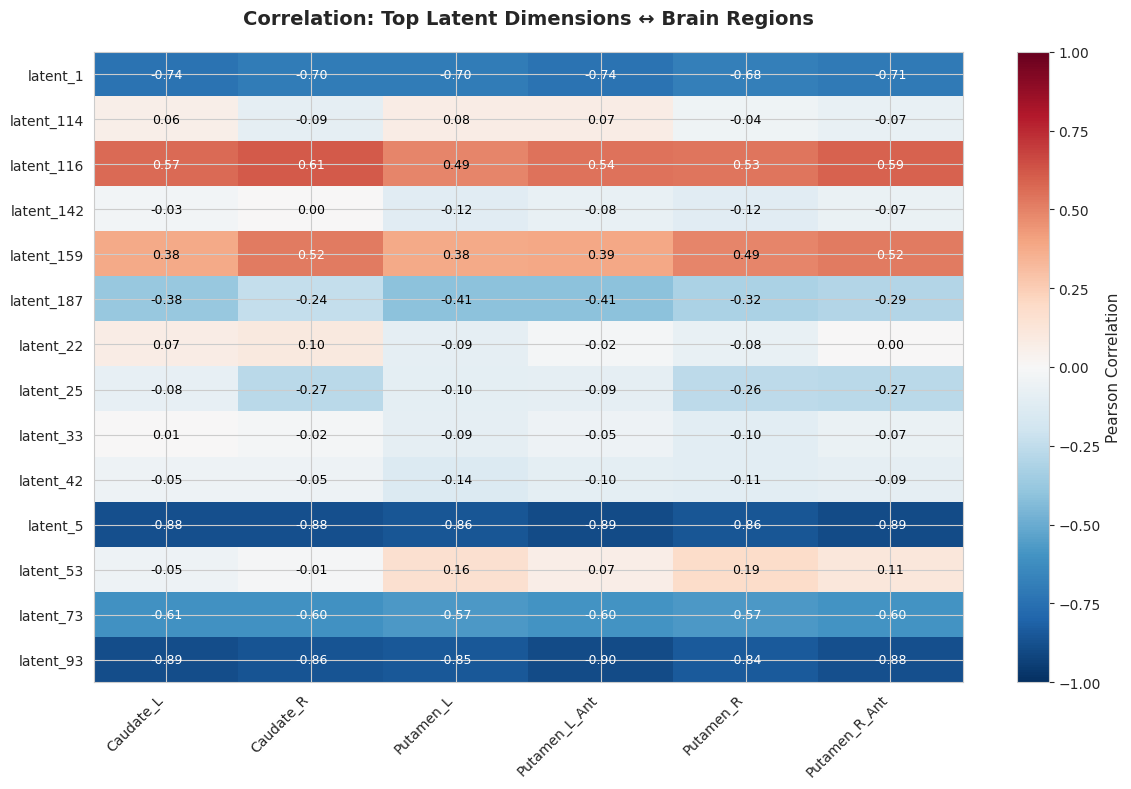

Plot saved to: output/latent_brain_region_correlations.png


In [7]:
# Create correlation matrix
corr_matrix = df_corr.pivot(index='Latent_Dim', columns='Brain_Region', values='Correlation')

# Reorder for better visualization
corr_matrix = corr_matrix.reindex(all_top_dims)
corr_matrix = corr_matrix[sorted(BRAIN_REGIONS.keys())]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(corr_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index, fontsize=10)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Pearson Correlation', fontsize=11)

# Add values to cells
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        text = ax.text(j, i, f'{val:.2f}',
                       ha="center", va="center", 
                       color="white" if abs(val) > 0.5 else "black", fontsize=9)

ax.set_title('Correlation: Top Latent Dimensions ↔ Brain Regions', 
            fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('output/latent_brain_region_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/latent_brain_region_correlations.png")

### 3.2 Top Correlations Bar Plot

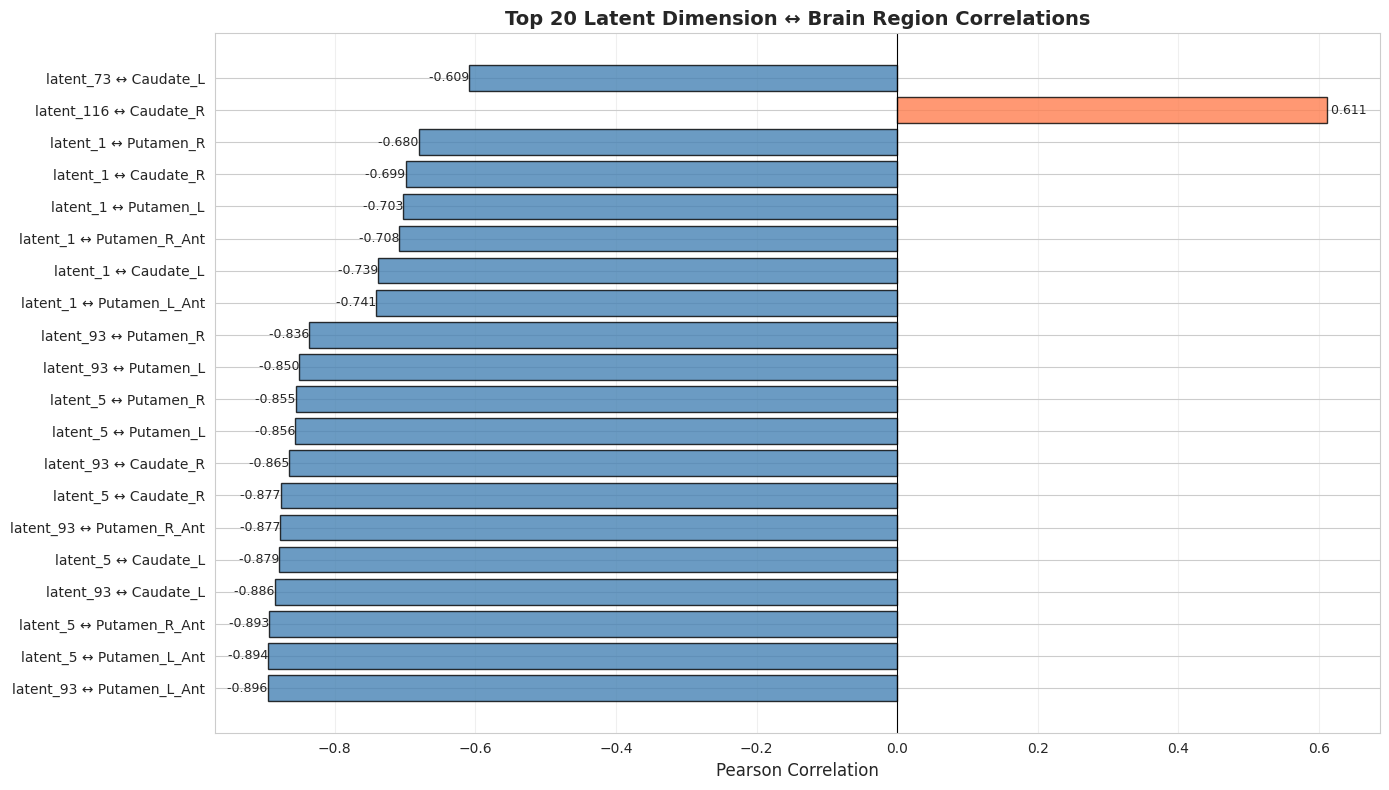

Plot saved to: output/top_latent_brain_correlations.png


In [8]:
fig, ax = plt.subplots(figsize=(14, 8))

# Get top 20 correlations
top_corr = df_corr.head(20).copy()
top_corr['Label'] = top_corr['Latent_Dim'] + ' ↔ ' + top_corr['Brain_Region']

# Color by sign
colors = ['coral' if x > 0 else 'steelblue' for x in top_corr['Correlation']]

ax.barh(range(len(top_corr)), top_corr['Correlation'], color=colors, edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr['Label'], fontsize=10)
ax.set_xlabel('Pearson Correlation', fontsize=12)
ax.set_title('Top 20 Latent Dimension ↔ Brain Region Correlations', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# Add value labels
for i, (label, corr) in enumerate(zip(top_corr['Label'], top_corr['Correlation'])):
    ax.text(corr, i, f' {corr:.3f}', va='center', 
           ha='left' if corr > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('output/top_latent_brain_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/top_latent_brain_correlations.png")

### 3.3 Scatter Plots: Top Latent Dimensions vs Brain Regions

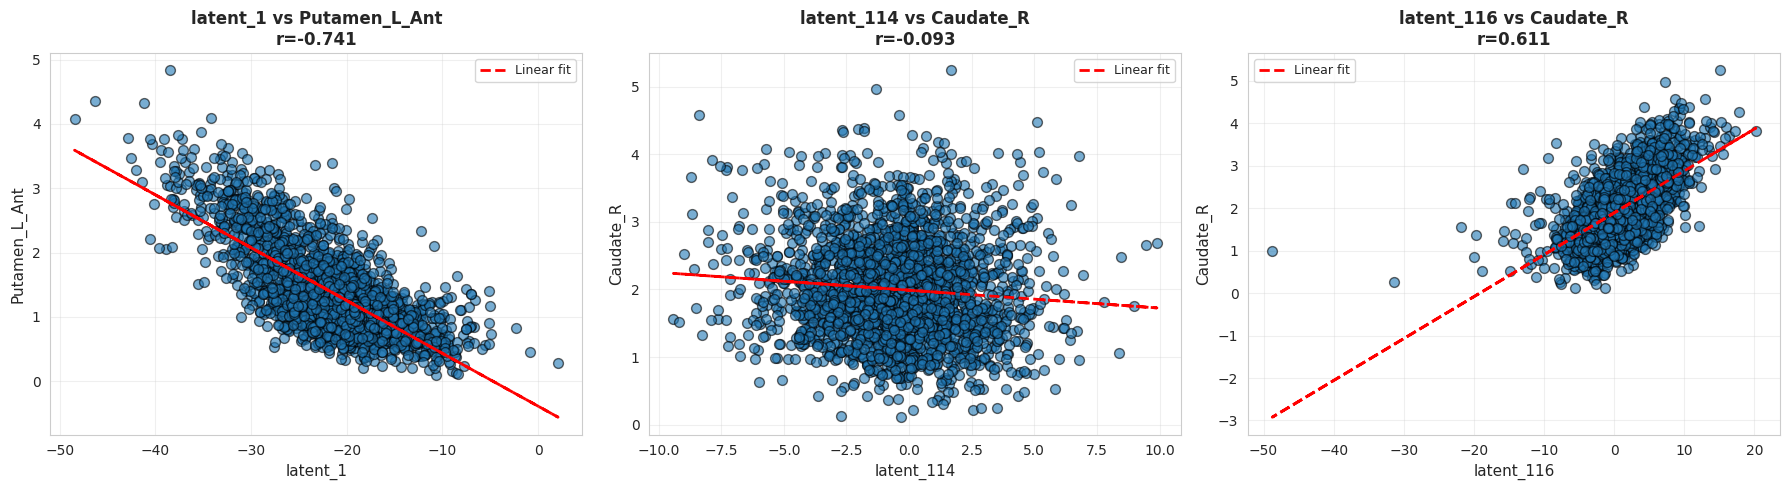

Plot saved to: output/top_latent_brain_scatter.png


In [9]:
# Select top 3 latent dimensions
top_3_dims = all_top_dims[:3]  # latent_93, latent_5, latent_25

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, latent_dim in enumerate(top_3_dims):
    # Find most correlated brain region for this dimension
    dim_corr = df_corr[df_corr['Latent_Dim'] == latent_dim].sort_values('Abs_Correlation', ascending=False)
    top_region = dim_corr.iloc[0]['Brain_Region']
    top_corr_val = dim_corr.iloc[0]['Correlation']
    
    # Get data
    latent_vals = df_sbr[latent_dim].values
    region_vals = df_sbr[BRAIN_REGIONS[top_region]].values
    
    # Scatter plot
    axes[idx].scatter(latent_vals, region_vals, alpha=0.6, edgecolor='black', s=50)
    
    # Add regression line
    z = np.polyfit(latent_vals, region_vals, 1)
    p = np.poly1d(z)
    axes[idx].plot(latent_vals, p(latent_vals), "r--", linewidth=2, label=f'Linear fit')
    
    axes[idx].set_xlabel(latent_dim, fontsize=11)
    axes[idx].set_ylabel(top_region, fontsize=11)
    axes[idx].set_title(f'{latent_dim} vs {top_region}\nr={top_corr_val:.3f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.savefig('output/top_latent_brain_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/top_latent_brain_scatter.png")

## Section 4: Summary and Interpretation

### 4.1 Key Findings

In [10]:
print("\n" + "="*80)
print("KEY FINDINGS: LATENT DIMENSIONS AND BRAIN REGIONS")
print("="*80)

# Find strongest correlations
strongest = df_corr.iloc[0]
print(f"\nStrongest correlation:")
print(f"  {strongest['Latent_Dim']} ↔ {strongest['Brain_Region']}")
print(f"  r = {strongest['Correlation']:.4f}, p = {strongest['P_Value']:.2e}")

# Check if dimensions are region-specific
print(f"\nRegion-Specificity Analysis:")
for dim in all_top_dims:
    dim_corr = df_corr[df_corr['Latent_Dim'] == dim].sort_values('Abs_Correlation', ascending=False)
    top_region = dim_corr.iloc[0]['Brain_Region']
    top_corr = dim_corr.iloc[0]['Correlation']
    
    # Check if this dimension is more correlated with one region
    top_3_corrs = dim_corr.head(3)['Abs_Correlation'].values
    specificity = top_3_corrs[0] - top_3_corrs[2]  # Difference between 1st and 3rd
    
    print(f"\n  {dim}:")
    print(f"    Most correlated: {top_region} (r={top_corr:.4f})")
    print(f"    Specificity score: {specificity:.4f}")
    if specificity > 0.1:
        print(f"    → Region-specific (concentrated on one region)")
    else:
        print(f"    → Distributed (correlates with multiple regions)")


KEY FINDINGS: LATENT DIMENSIONS AND BRAIN REGIONS

Strongest correlation:
  latent_93 ↔ Putamen_L_Ant
  r = -0.8956, p = 0.00e+00

Region-Specificity Analysis:

  latent_1:
    Most correlated: Putamen_L_Ant (r=-0.7410)
    Specificity score: 0.0327
    → Distributed (correlates with multiple regions)

  latent_114:
    Most correlated: Caudate_R (r=-0.0932)
    Specificity score: 0.0190
    → Distributed (correlates with multiple regions)

  latent_116:
    Most correlated: Caudate_R (r=0.6114)
    Specificity score: 0.0416
    → Distributed (correlates with multiple regions)

  latent_142:
    Most correlated: Putamen_L (r=-0.1166)
    Specificity score: 0.0398
    → Distributed (correlates with multiple regions)

  latent_159:
    Most correlated: Caudate_R (r=0.5214)
    Specificity score: 0.0317
    → Distributed (correlates with multiple regions)

  latent_187:
    Most correlated: Putamen_L_Ant (r=-0.4112)
    Specificity score: 0.0327
    → Distributed (correlates with multipl

### 4.2 Save Results

In [11]:
# Save correlation results
output_dir = Path('output')

df_corr.to_csv(output_dir / 'latent_brain_region_correlations.csv', index=False)
corr_matrix.to_csv(output_dir / 'latent_brain_region_correlation_matrix.csv')

print("Results saved to:")
print(f"  - {output_dir / 'latent_brain_region_correlations.csv'}")
print(f"  - {output_dir / 'latent_brain_region_correlation_matrix.csv'}")

Results saved to:
  - output/latent_brain_region_correlations.csv
  - output/latent_brain_region_correlation_matrix.csv
